# Development of a particle surfacing algorithm

In [4]:
import sys

from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np

from matplotlib import colors
from numpy.typing import NDArray
from scipy import ndimage
from skimage.measure import marching_cubes

from surfacing.particle_extractor import ParticleExtractor, blend_particle


project_root = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from cfg_data import AnalysisBase  # ignore ruff E402

plt.style.use("dark_background")
cfg_path = project_root / "config.toml"

# For running the 3D viewer.
%matplotlib widget


## Blending function
Embeds the particle into an image

In [5]:
'''def blend_particle(
    image: NDArray[np.uint8],
    particle: NDArray[np.floating],
    particle_center: tuple[int, int],
    blur: float = 1.0,
    truncate_filter: float = 2.0,
    gain: float = 0.75,
) -> NDArray[np.uint8]:
    """Blend a projected particle into an image.

    The particle is embedded at ``particle_center``, optionally blurred
    with a Gaussian filter, scaled by ``gain``, and added to the image.
    ``truncate_filter`` controls the Gaussian kernel support in units of
    the blur standard deviation: the filter radius is approximately
    ``blur * truncate_filter`` pixels on each side of the kernel.

    Args:
        image: Two-dimensional uint8 image to which the particle is added.
        particle: Two-dimensional projected particle intensity array.
        particle_center: ``(y, x)`` location of the particle center in
            ``image`` coordinates.
        blur: Gaussian-filter standard deviation in pixels. A value of
            zero disables blurring.
        truncate_filter: Gaussian-filter truncation radius in units of
            ``blur``. Smaller values produce shorter filter tails.
        gain: Multiplicative intensity applied to the blurred particle
            before it is added to the image.

    Returns:
        The blended image clipped to ``[0, 255]`` and converted to
        ``np.uint8``.

    Raises:
        ValueError: If the inputs are not two-dimensional, ``blur`` is
            negative, or the requested Gaussian kernel is too narrow.
    """
    if image.ndim != 2 or particle.ndim != 2:
        raise ValueError("image and particle must both be 2D arrays")
    if blur < 0:
        raise ValueError("blur must be non-negative")
    if blur * truncate_filter < 1.5:
        raise ValueError("blur * truncate_filter must be at least 1.5")

    def _embed_particle(
        particle: NDArray[np.floating],
        shape: tuple[int, int],
        location: tuple[int, int],
    ) -> NDArray[np.floating]:
        """
        Embed a particle image into an array of the given shape at the specified location.
        Args:
            particle: Two-dimensional projected particle intensity array.
            shape: Shape of the output array.
            location: ``(y, x)`` location of the particle center in the output array.

        Returns:
            The embedded particle image as a floating-point array of the specified shape.
        """
        embedded_particle = np.zeros(shape, dtype=np.float32)
        y0, x0 = location
        y_start = y0 - particle.shape[0] // 2
        x_start = x0 - particle.shape[1] // 2
        y_stop = y_start + particle.shape[0]
        x_stop = x_start + particle.shape[1]

        iy0, iy1 = max(y_start, 0), min(y_stop, shape[0])
        ix0, ix1 = max(x_start, 0), min(x_stop, shape[1])
        if iy0 < iy1 and ix0 < ix1:
            py0, px0 = iy0 - y_start, ix0 - x_start
            py1, px1 = py0 + (iy1 - iy0), px0 + (ix1 - ix0)
            embedded_particle[iy0:iy1, ix0:ix1] = particle[py0:py1, px0:px1]

        return embedded_particle

    embedded_particle = _embed_particle(particle, image.shape, particle_center)
    # embedded_particle = np.zeros(image.shape, dtype=np.float32)
    # y0, x0 = particle_center
    # y_start = y0 - particle.shape[0] // 2
    # x_start = x0 - particle.shape[1] // 2
    # y_stop = y_start + particle.shape[0]
    # x_stop = x_start + particle.shape[1]

    # # Clip the insertion window so edge-adjacent particles are supported.
    # iy0, iy1 = max(y_start, 0), min(y_stop, image.shape[0])
    # ix0, ix1 = max(x_start, 0), min(x_stop, image.shape[1])
    # if iy0 < iy1 and ix0 < ix1:
    #     py0, px0 = iy0 - y_start, ix0 - x_start
    #     py1, px1 = py0 + (iy1 - iy0), px0 + (ix1 - ix0)
    #     embedded_particle[iy0:iy1, ix0:ix1] = particle[py0:py1, px0:px1]

    if blur > 0 and embedded_particle.max() > 0:
        original_max = embedded_particle.max()
        embedded_particle = ndimage.gaussian_filter(
            embedded_particle, sigma=blur, truncate=truncate_filter
        )
        blurred_max = embedded_particle.max()
        if blurred_max > 0:
            embedded_particle *= original_max / blurred_max

    particle_added = image + gain * embedded_particle
    return np.clip(np.rint(particle_added), 0, 255).astype(np.uint8)

'''


def embed_particle(
    particle: NDArray[np.floating],
    shape: tuple[int, int],
    location: tuple[int, int],
) -> NDArray[np.floating]:
    """
    Embed a particle image into an array of the given shape at the specified location.
    Args:
        particle: Two-dimensional projected particle intensity array.
        shape: Shape of the output array.
        location: ``(y, x)`` location of the particle center in the output array.

    Returns:
        The embedded particle image as a floating-point array of the specified shape.
    """
    embedded_particle = np.zeros(shape, dtype=np.float32)
    y0, x0 = location
    y_start = y0 - particle.shape[0] // 2
    x_start = x0 - particle.shape[1] // 2
    y_stop = y_start + particle.shape[0]
    x_stop = x_start + particle.shape[1]

    iy0, iy1 = max(y_start, 0), min(y_stop, shape[0])
    ix0, ix1 = max(x_start, 0), min(x_stop, shape[1])
    if iy0 < iy1 and ix0 < ix1:
        py0, px0 = iy0 - y_start, ix0 - x_start
        py1, px1 = py0 + (iy1 - iy0), px0 + (ix1 - ix0)
        embedded_particle[iy0:iy1, ix0:ix1] = particle[py0:py1, px0:px1]

    return embedded_particle

## 3D rendering function

In [6]:
def render_3d(
    mask: NDArray[np.bool_],
    volume: NDArray[np.float32],
    scale_factor: float,
    render_mode: Literal["surface", "voxels"] = "surface",
    resolution: int = 4,
    clip_level: float = 2.5,
    spline_order: int = 3,
    colormap: str = "inferno",
):
    """Render a 3D visualization of a masked volume.

    Args:
      mask: A 3D boolean array indicating the regions of interest.
      volume: A 3D array representing the volume data.
      scale_factor: Factor used to express the volume in noise-standard-deviation units.
      render_mode: Either ``"surface"`` or ``"voxels"``.
      resolution: Resolution factor used for smoothing.
      clip_level: Isosurface level for the marching-cubes algorithm.
      spline_order: Spline order used for smoothing.
      colormap: Matplotlib colormap name.
    """
    import matplotlib

    if mask.ndim != 3:
        raise ValueError("mask must be a 3D array")
    if volume.ndim != 3:
        raise ValueError("volume must be a 3D array")
    if mask.shape != volume.shape:
        raise ValueError("mask and volume must have the same shape")
    if scale_factor == 0:
        raise ValueError("scale_factor must not be zero")
    if render_mode not in ["surface", "voxels"]:
        raise ValueError("render_mode must be either 'surface' or 'voxels'")

    cmap = plt.colormaps[colormap]

    # Convert the signal to local noise-standard-deviation units.
    scaled_zyx = volume.astype(np.float32) / float(scale_factor)

    # Convert from z, y, x to x, y, z for Matplotlib.
    mask_xyz = mask.transpose(2, 1, 0)
    scaled_xyz = scaled_zyx.transpose(2, 1, 0)
    voxel_values = scaled_xyz[mask_xyz]
    if voxel_values.size == 0:
        raise ValueError("The mask does not select any voxels in the volume")

    vmin = float(np.min(voxel_values.min()))
    vmax = float(np.max(voxel_values.max()))
    if np.isclose(vmin, vmax):
        margin = max(abs(vmax) * 0.01, 1e-6)
        vmin -= margin
        vmax += margin

    norm = colors.Normalize(
        vmin=vmin,
        vmax=vmax,
    )
    colorbar_mappable = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
    colorbar_mappable.set_array(voxel_values)

    figure_name = "3D-Volume-Rendering-code-01"
    plt.close(figure_name)

    fig = plt.figure(figsize=(8, 7), num=figure_name)
    ax = fig.add_subplot(111, projection="3d")

    if render_mode == "voxels":
        facecolors = cmap(norm(scaled_xyz))
        facecolors[..., 3] = np.where(mask_xyz, 0.95, 0.0)

        ax.voxels(
            mask_xyz,
            facecolors=facecolors,
            edgecolor=(1.0, 1.0, 1.0, 0.35),
            linewidth=0.5,
            shade=True,
        )
    else:
        smooth_scaled = ndimage.zoom(
            scaled_xyz * mask_xyz,
            resolution,
            order=spline_order,
        )

        verts, faces, _, _ = marching_cubes(
            smooth_scaled,
            level=clip_level,
            spacing=(1 / resolution,) * 3,
        )

        # ``spacing`` already expresses vertices in original-volume voxel
        # coordinates, so do not multiply by ``resolution`` again.
        vert_idxs = np.rint(verts).astype(int)

        for axis, size in enumerate(mask_xyz.shape):
            vert_idxs[:, axis] = np.clip(
                vert_idxs[:, axis],
                0,
                size - 1,
            )

        nearest_inside = ndimage.distance_transform_edt(
            ~mask_xyz,
            return_distances=False,
            return_indices=True,
        )

        inside_indices = nearest_inside[
            :,
            vert_idxs[:, 0],
            vert_idxs[:, 1],
            vert_idxs[:, 2],
        ]

        vert_values = scaled_xyz[
            inside_indices[0],
            inside_indices[1],
            inside_indices[2],
        ]
        face_values = vert_values[faces].mean(axis=1)

        surface = ax.plot_trisurf(
            verts[:, 2],
            verts[:, 1],
            verts[:, 0],
            triangles=faces,
            cmap=colormap,
            norm=norm,
            linewidth=0,
            antialiased=True,
            alpha=0.9,
            shade=False,
        )
        # Color each surface face from the sampled intensity values.
        surface.set_array(face_values)
    fig.colorbar(
        colorbar_mappable,
        ax=ax,
        shrink=0.65,
        pad=0.1,
        label="Intensity",
    )

    nx, ny, nz = mask_xyz.shape

    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_zlim(0, nz)
    ax.set_box_aspect((nx, ny, nz))

    ax.set_xlabel("x [voxel]")
    ax.set_ylabel("y [voxel]")
    ax.set_zlabel("z [voxel]")

    plt.tight_layout()
    plt.show()


## Load a volume and inspect a slice

In [7]:
vol_idx: int = 0
vol_obj = AnalysisBase(cfg_path, vol_index=vol_idx, exp_index=0)
vol_data = vol_obj.vol
vol_shape = vol_data.shape

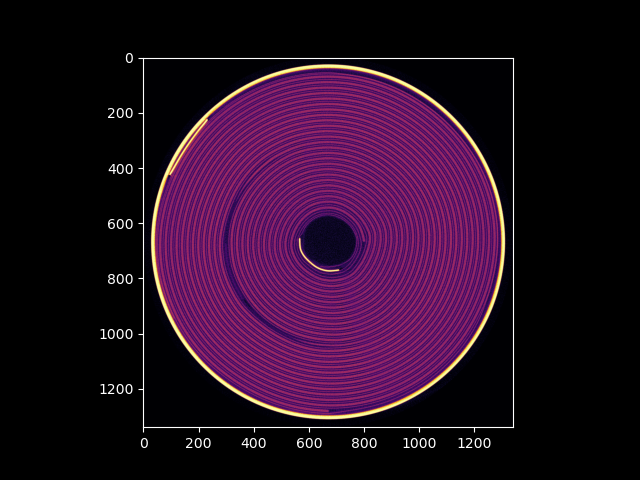

In [8]:
plt.close("all")
_slice = vol_data[vol_shape[0] // 2]
plt.imshow(_slice, cmap="inferno")
plt.show()

## Particle extraction and visualization

In [9]:
# Set the point where the particle is located
p_zyx = (1000, 380, 380)  # just background location
p_zyx = (144, 409, 562)  # partcle location

# Set the particle slice
particle_slice = vol_data[p_zyx[0]]

# Set the particle slab
slab_thickness = 61
particle_slab = vol_data[
    p_zyx[0] - slab_thickness // 2 : p_zyx[0] + slab_thickness // 2 + 1
]


# Set up the particle extractor
p_extractor = ParticleExtractor(
    vol_data
)  # Replace 'enhancer_class' with the actual class name for the enhancer object
p_extractor.set_voxel_location(p_zyx)
particle_3d = p_extractor.particle
if particle_3d.max() <= 0:
    print("No particle found at the specified location.")
else:
    print("Particle found.")

particle_projection = p_extractor.project_particle()

Particle found.


## 2D Particle Rendering

### Render the Particle and Slice in the Local Neighborhood

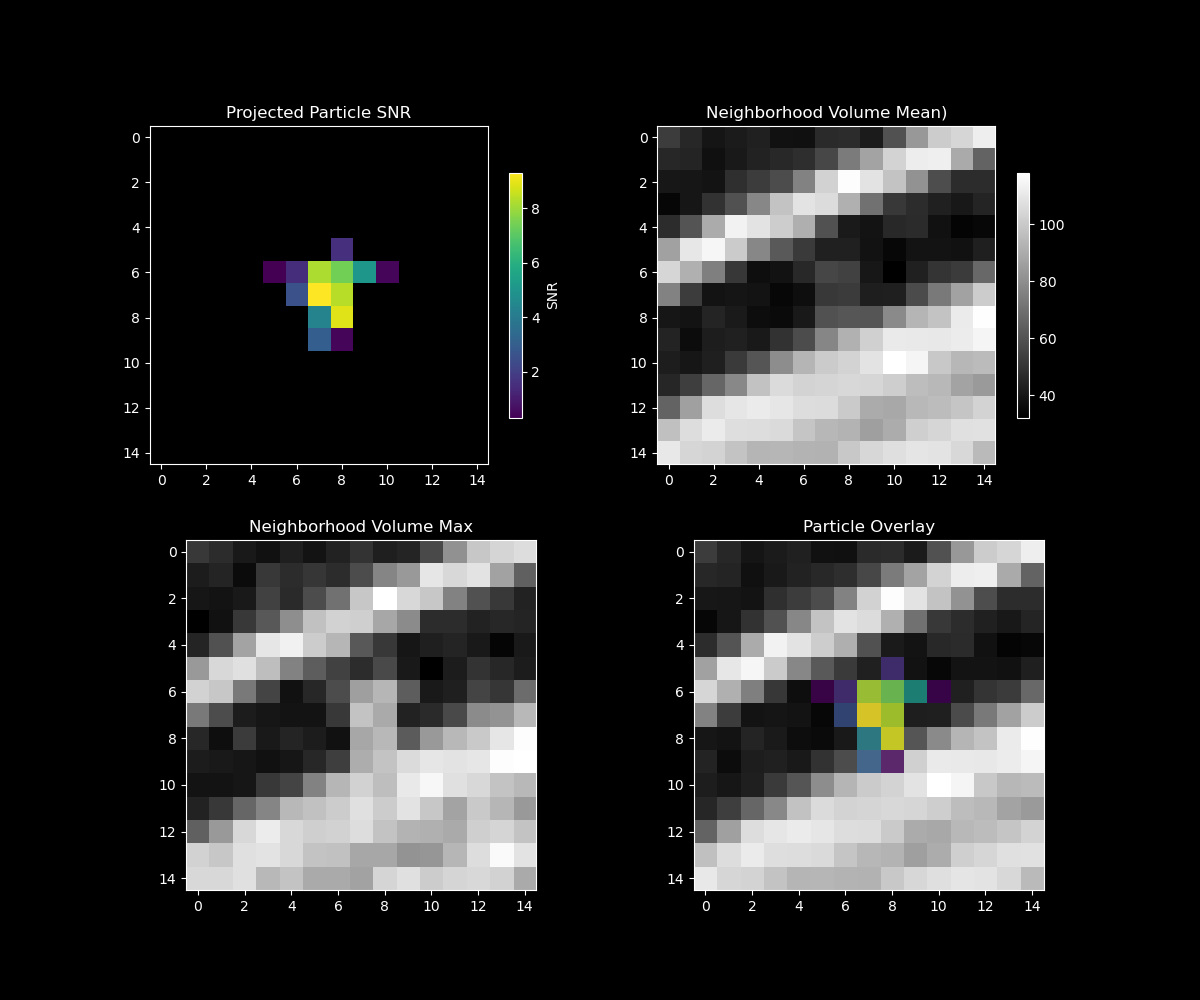

In [10]:
# Render the particle projection
import matplotlib.pyplot as plt

noise_level = p_extractor.noise_estimate
particle_support = particle_projection > 0
overlay_mask = np.ma.masked_where(~particle_support, particle_projection / noise_level)

plt.close("all")
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(overlay_mask, cmap="viridis")
plt.colorbar(shrink=0.7, label="SNR")
plt.title("Projected Particle SNR")

plt.subplot(2, 2, 2)
_img = p_extractor.get_neighborhood_volume().mean(axis=0)
plt.imshow(_img, cmap="gray")
plt.colorbar(shrink=0.7)
plt.title("Neighborhood Volume Mean)")

plt.subplot(2, 2, 3)
plt.imshow(p_extractor.get_neighborhood_volume().max(axis=0), cmap="gray")
plt.title("Neighborhood Volume Max")

plt.subplot(2, 2, 4)
plt.imshow(_img, cmap="gray")
plt.imshow(overlay_mask, cmap="viridis", alpha=0.8)
plt.title("Particle Overlay")


plt.show()

### Render the Blended Particle Into the Full Slice

<class 'matplotlib.figure.Figure'>


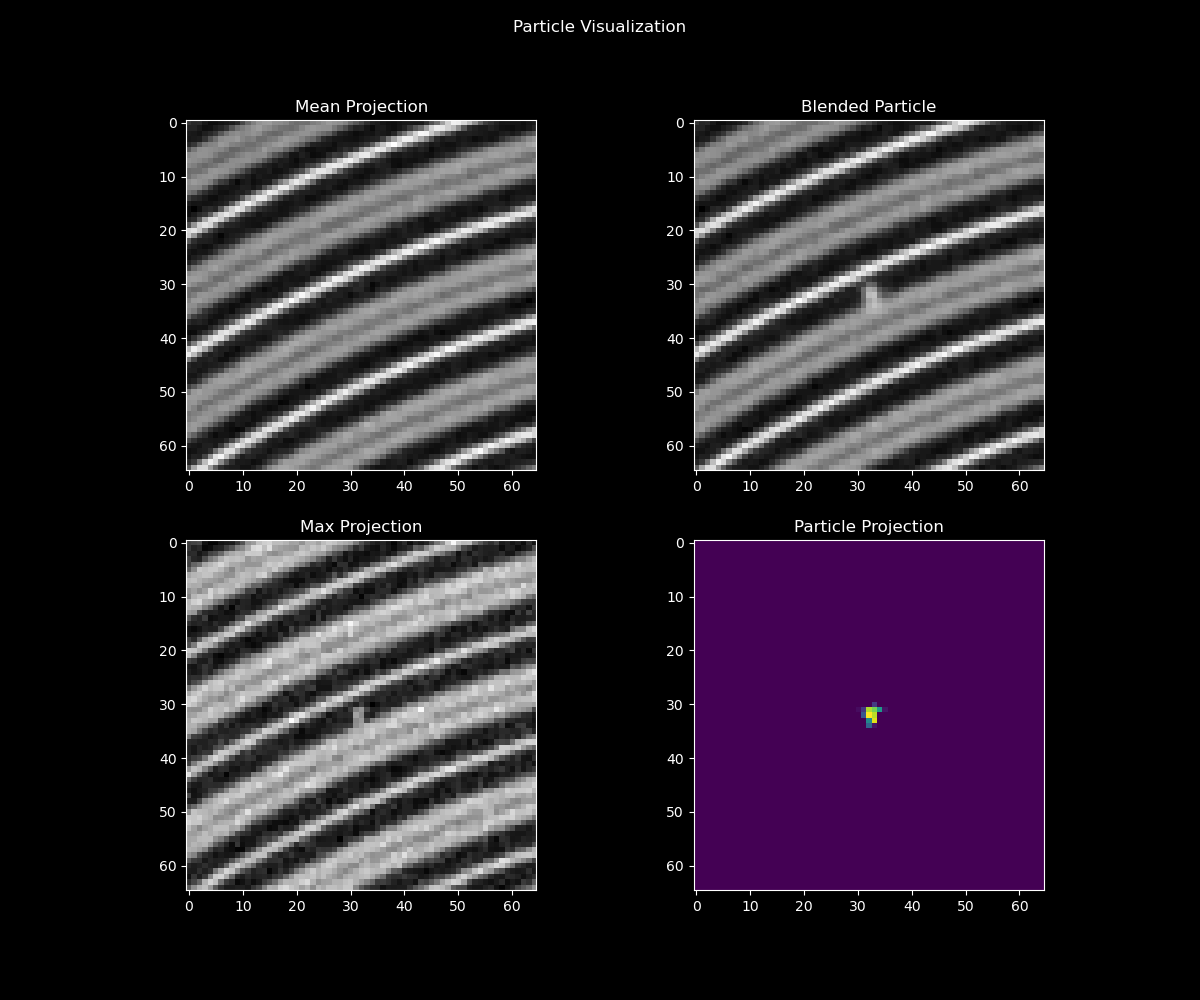

In [11]:
blended = blend_particle(
    image=particle_slab.mean(axis=0),
    particle=particle_projection,
    particle_center=(p_zyx[1], p_zyx[2]),
    blur=1.0,  # optional, apply Gaussian blur to the embedded particle,
    truncate_filter=4.0,  # optional, set the truncate parameter for the Gaussian blur
)

max_projection = particle_slab.max(axis=0)
mean_projection = particle_slab.mean(axis=0)

# Set up the local neighborhood for visualization
l_extent = 64
r_slice = slice(p_zyx[1] - l_extent // 2, p_zyx[1] + l_extent // 2 + 1)
c_slice = slice(p_zyx[2] - l_extent // 2, p_zyx[2] + l_extent // 2 + 1)

plt.close("all")

fig = plt.figure(figsize=(12, 10))
fig.suptitle("Particle Visualization")

print(type(fig))
plt.subplot(2, 2, 1)
plt.imshow(mean_projection[r_slice, c_slice], cmap="gray")
plt.title("Mean Projection")

plt.subplot(2, 2, 2)
plt.imshow(blended[r_slice, c_slice], cmap="gray")
plt.title("Blended Particle")

plt.subplot(2, 2, 3)
plt.imshow(max_projection[r_slice, c_slice], cmap="gray")
plt.title("Max Projection")

plt.subplot(2, 2, 4)
embedded_particle = embed_particle(
    particle=particle_projection,
    shape=mean_projection.shape,
    location=(p_zyx[1], p_zyx[2]),
)
plt.imshow(embedded_particle[r_slice, c_slice], cmap="viridis")#
plt.title("Particle Projection")

plt.show()

## 3D Particle Rendering

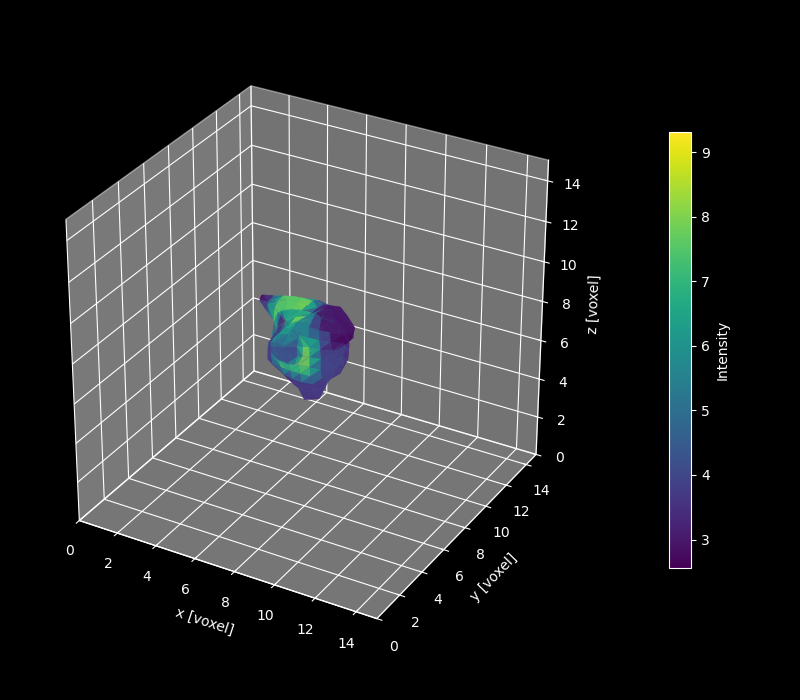

In [12]:
_volume_data = p_extractor.particle
_scale_factor = p_extractor.noise_estimate  # scales values to snr
_clip_level = (
    2.5  # how to cut values for the surface of the particle, increase to get deeper
)

_mask = _volume_data > 0
if _mask.any():
    render_3d(
        mask=_volume_data > 0,
        volume=_volume_data,
        scale_factor=_scale_factor,
        resolution=2,
        clip_level=_clip_level,
        spline_order=3,
        colormap="viridis",
        render_mode="surface",
    )
else:
    print("No positive values in the volume data.")
